In [17]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv('Algerian_forest_fires_cleaned_data.csv')

In [19]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,1
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,1
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,1


In [20]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [21]:
df.drop(['day', 'month', 'year'], axis = 1, inplace = True)

In [22]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,1
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,1
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,1


In [23]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [24]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),1,0)

In [25]:
df.sample(10)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
209,35,56,14,0.4,79.2,37.0,166.0,2.1,30.6,6.1,1,0
22,32,62,18,0.1,81.4,8.2,47.7,3.3,11.5,3.8,0,1
82,36,55,18,0.0,89.1,33.5,151.3,9.9,43.1,20.4,0,1
169,34,58,16,0.0,88.1,27.8,61.1,7.3,27.7,13.0,0,0
199,37,37,14,0.0,94.3,35.9,86.8,16.0,35.9,26.3,0,0
204,36,43,16,0.0,91.2,46.1,137.7,11.5,50.2,24.5,0,0
50,33,70,17,0.0,85.4,18.5,71.5,5.2,22.4,8.8,0,1
119,32,47,14,0.7,77.5,7.1,8.8,1.8,6.8,0.9,1,1
144,33,59,16,0.8,74.2,7.0,8.3,1.6,6.7,0.8,1,0
137,29,87,15,0.4,47.4,4.2,8.0,0.2,4.1,0.1,1,0


In [26]:
df['Classes'].value_counts()

Classes
0    137
1    106
Name: count, dtype: int64

In [27]:
X = df.drop(['FWI'],axis=1)
y = df['FWI']

In [28]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,1,1
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,1,1
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,1,1
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,1,1
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,1,1


In [29]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [33]:
X_train.shape, X_test.shape

((194, 11), (49, 11))

In [34]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.653725,-0.308149,-0.313112,0.690285,0.468911,0.372163,0.613138,0.446280,-0.539642,-0.258344
RH,-0.653725,1.000000,0.211645,0.239441,-0.649239,-0.401836,-0.220945,-0.714640,-0.346511,0.454926,0.408441
Ws,-0.308149,0.211645,1.000000,0.235922,-0.176596,0.004712,0.092866,-0.002300,0.037465,0.075322,0.202357
Rain,-0.313112,0.239441,0.235922,1.000000,-0.547864,-0.288538,-0.301110,-0.349903,-0.299179,0.378585,0.057382
FFMC,0.690285,-0.649239,-0.176596,-0.547864,1.000000,0.611978,0.519513,0.751819,0.598248,-0.786012,-0.254770
DMC,0.468911,-0.401836,0.004712,-0.288538,0.611978,1.000000,0.876122,0.679049,0.983891,-0.606775,-0.188980
DC,0.372163,-0.220945,0.092866,-0.301110,0.519513,0.876122,1.000000,0.512934,0.946181,-0.538893,0.083038
ISI,0.613138,-0.714640,-0.002300,-0.349903,0.751819,0.679049,0.512934,1.000000,0.637669,-0.740072,-0.291889
BUI,0.446280,-0.346511,0.037465,-0.299179,0.598248,0.983891,0.946181,0.637669,1.000000,-0.602102,-0.090326
Classes,-0.539642,0.454926,0.075322,0.378585,-0.786012,-0.606775,-0.538893,-0.740072,-0.602102,1.000000,0.196276


<Axes: >

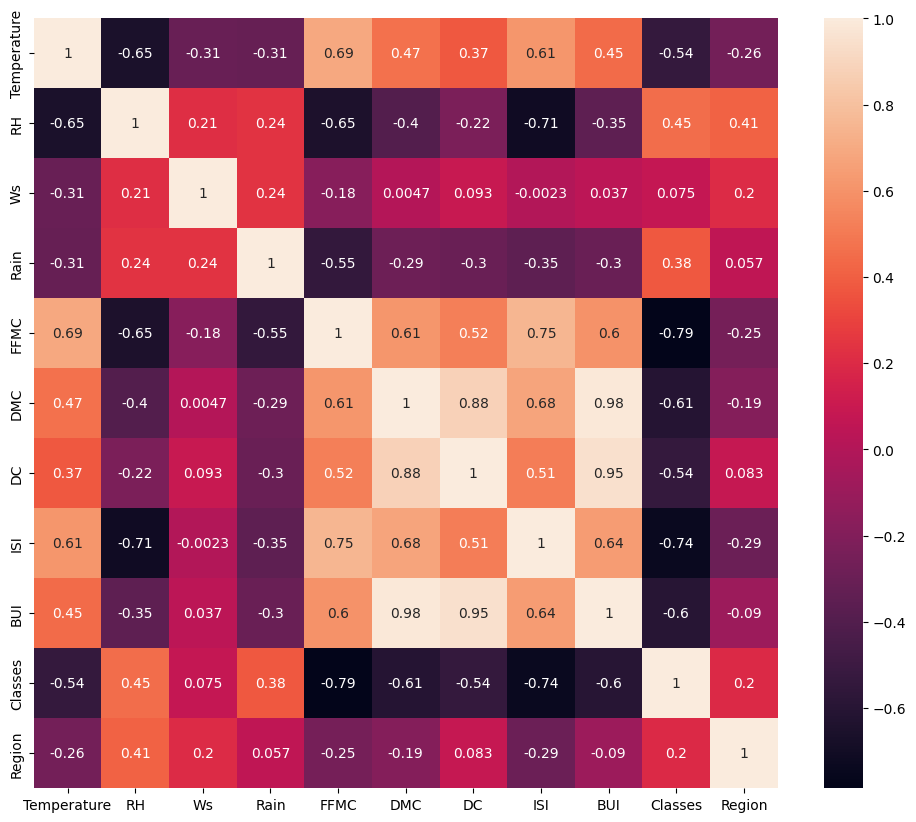

In [36]:
plt.figure(figsize = (12,10))
corr = X_train.corr()
sns.heatmap(corr, annot = True)

In [37]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.653725,-0.308149,-0.313112,0.690285,0.468911,0.372163,0.613138,0.446280,-0.539642,-0.258344
RH,-0.653725,1.000000,0.211645,0.239441,-0.649239,-0.401836,-0.220945,-0.714640,-0.346511,0.454926,0.408441
Ws,-0.308149,0.211645,1.000000,0.235922,-0.176596,0.004712,0.092866,-0.002300,0.037465,0.075322,0.202357
Rain,-0.313112,0.239441,0.235922,1.000000,-0.547864,-0.288538,-0.301110,-0.349903,-0.299179,0.378585,0.057382
FFMC,0.690285,-0.649239,-0.176596,-0.547864,1.000000,0.611978,0.519513,0.751819,0.598248,-0.786012,-0.254770
DMC,0.468911,-0.401836,0.004712,-0.288538,0.611978,1.000000,0.876122,0.679049,0.983891,-0.606775,-0.188980
DC,0.372163,-0.220945,0.092866,-0.301110,0.519513,0.876122,1.000000,0.512934,0.946181,-0.538893,0.083038
ISI,0.613138,-0.714640,-0.002300,-0.349903,0.751819,0.679049,0.512934,1.000000,0.637669,-0.740072,-0.291889
BUI,0.446280,-0.346511,0.037465,-0.299179,0.598248,0.983891,0.946181,0.637669,1.000000,-0.602102,-0.090326
Classes,-0.539642,0.454926,0.075322,0.378585,-0.786012,-0.606775,-0.538893,-0.740072,-0.602102,1.000000,0.196276


In [38]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [39]:
## threshold--Domain expertise
corr_features=correlation(X_train,0.85)

In [40]:
corr_features

{'BUI', 'DC'}

In [41]:
## drop features when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((194, 9), (49, 9))

In [42]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [43]:
X_train_scaled

array([[-0.87563202,  0.21321832,  1.28577038, ..., -0.79648833,
         1.14434427,  1.01036297],
       [ 0.22209084, -1.65484925,  0.14504117, ...,  1.88757476,
        -0.8738629 , -0.98974332],
       [ 1.5942444 , -1.25454906, -0.99568804, ..., -0.19488798,
        -0.8738629 , -0.98974332],
       ...,
       [-1.97335488,  0.947102  ,  0.52528424, ..., -1.0972885 ,
         1.14434427,  1.01036297],
       [ 0.49652155, -0.18708188,  0.14504117, ...,  0.56868169,
        -0.8738629 , -0.98974332],
       [-0.60120131,  1.0138187 ,  2.04625653, ..., -0.88904223,
         1.14434427,  1.01036297]], shape=(194, 9))

Text(0.5, 1.0, 'X_train After Scaling')

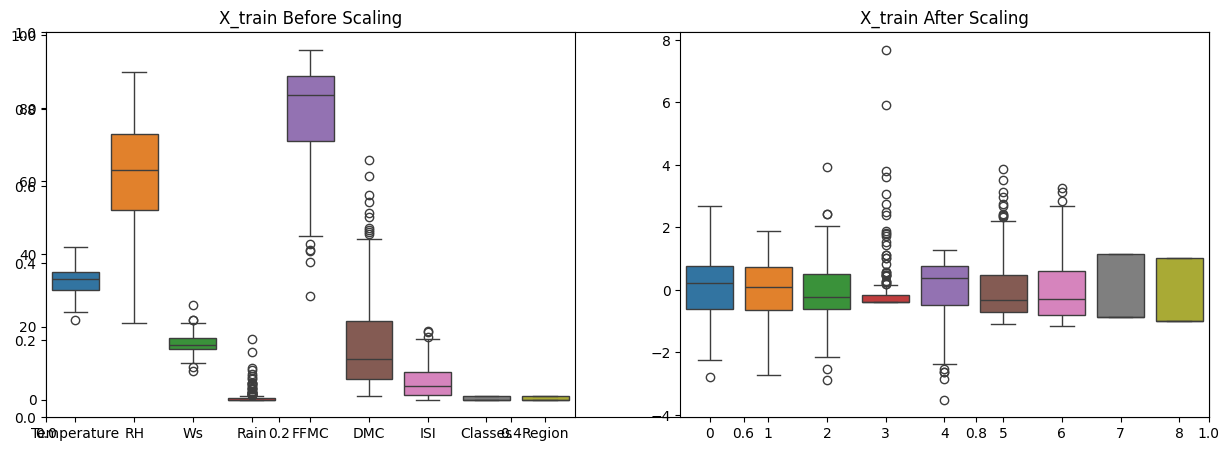

In [44]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.5049978694165684
R2 Score 0.9805895859259882


In [46]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 1.0093958923873403
R2 Score 0.9430507350726564


In [47]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.5192048325844753
R2 Score 0.9801058063273601


In [48]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 1.6834416340136715
R2 Score 0.8676961352267807


In [49]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))